In [54]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from typing import Annotated, Optional, Literal
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field

In [55]:
import operator

In [56]:
from langchain_core.prompts import PromptTemplate

In [57]:
class Score(BaseModel):
    score : int = Field(description = "Score of essay")
    feedback : str = Field(description="Feedback of essay")


In [58]:
class Summarized(BaseModel):
    feedback: str = Field(description = "Summarized Score of essay")

In [59]:
parser2 = PydanticOutputParser(pydantic_object=Summarized)

In [60]:
prompt2 = PromptTemplate(
    template="""Use this {feedback} three different aspect of feedbacks of essay to provide a summarized feedback.
        {format_instruction}""",
        input_variables=['feedback'],
        partial_variables={
        "format_instruction": parser2.get_format_instructions()}
)

In [61]:
parser = PydanticOutputParser(pydantic_object=Score)

In [62]:
essay = """India, one of the world’s oldest civilizations, is a nation celebrated for its diversity, culture, and history. Stretching from the majestic Himalayas in the north to the Indian Ocean in the south, it is the seventh largest country by area and the most populous in the world. India gained independence on 15 August 1947 under the leadership of Mahatma Gandhi, who championed non‑violence, and adopted its Constitution in 1950, making it the largest democracy globally.

The tricolor national flag symbolizes courage, peace, and prosperity, with the Ashoka Chakra representing progress. India’s 28 states and 8 union territories each have unique traditions, languages, and cuisines, reflecting unity in diversity. Festivals such as Diwali, Holi, Eid, and Christmas are celebrated with equal enthusiasm, showcasing harmony among communities.

Economically, India has a mixed system where agriculture sustains millions, while industry, services, and IT drive modern growth. Bollywood, the world’s largest film industry, adds to its global cultural influence. Heritage sites like the Taj Mahal, Jaipur, and Varanasi highlight its rich past, while yoga and Ayurveda contribute to global wellness.

India has also advanced in science and technology, with ISRO’s missions to the Moon and Mars. With its youth shaping the future, India stands as a vibrant nation of unity, progress, and innovation."""

In [63]:
prompt = PromptTemplate(
    template="""
Evaluate the following essay based on {x}.

Essay:
{essay}

{format_instruction}
""",
    input_variables=["essay", "x"],
    partial_variables={
        "format_instruction": parser.get_format_instructions()
    }
)

In [64]:
class UPSCState(TypedDict):
    essay : str
    cot_feedback : str
    doa_feedback : str
    language_feedback : str
    individual_score : Annotated[list[int], operator.add]
    avg_score : float
    final_feedback : str


In [65]:
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os
load_dotenv()



llm_endpoint = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="conversational",
    huggingfacehub_api_token=os.environ["HF_API_KEY_CONV"]
)


chat_model = ChatHuggingFace(llm=llm_endpoint)

In [66]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

llm1 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY1']
    # other params...
)

llm2 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY2']
    # other params...
)

llm3 = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=os.environ['GROQ_API_KEY3']
    # other params...
)

In [67]:
def cot(state : UPSCState):
    output = prompt | llm1 | parser
    out = output.invoke({'essay' : state['essay'], 'x': 'Clarity of thoughts'})
    feedback = out.feedback
    score = out.score
    return {'cot_feedback' : feedback, 'individual_score' : [score]}
     

In [68]:
def doa(state : UPSCState):
    output = prompt | llm2 | parser
    out = output.invoke({'essay' : state['essay'], 'x': 'depth of analysis'})
    feedback = out.feedback
    score = out.score
    return {'doa_feedback' : feedback, 'individual_score' : [score]}
     

In [69]:
def lf(state : UPSCState):
    output = prompt | llm3 | parser
    out = output.invoke({'essay' : state['essay'], 'x': 'language'})
    feedback = out.feedback
    score = out.score
    return {'language_feedback' : feedback, 'individual_score' : [score]}
     

In [70]:
def summarizer(state : UPSCState):
    output = prompt2 | llm3 | parser2
    strs = []
    strs.append(state['language_feedback'])
    strs.append(state['cot_feedback'])
    strs.append(state['doa_feedback'])
    out = output.invoke({'feedback': strs})
    avg = sum(state["individual_score"]) / 3
    return {'final_feedback' : out.feedback, 'avg_score':avg }

In [71]:
graph = StateGraph(UPSCState)



graph.add_node("cot", cot)
graph.add_node("doa", doa)
graph.add_node("lf", lf)
graph.add_node("summarizer", summarizer)



graph.add_edge(START, "cot")
graph.add_edge(START, "doa")
graph.add_edge(START, "lf")

graph.add_edge("cot", "summarizer")
graph.add_edge("doa", "summarizer")
graph.add_edge("lf", "summarizer")

graph.add_edge("summarizer", END)

workflow = graph.compile()



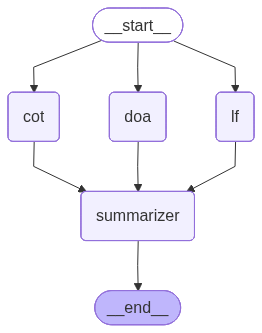

In [72]:
from IPython.display import Image
Image (workflow.get_graph().draw_mermaid_png())

In [ ]:
initial_state = {'essay' : essay}
final_state = workflow.invoke(initial_state)


{'essay': 'India, one of the world’s oldest civilizations, is a nation celebrated for its diversity, culture, and history. Stretching from the majestic Himalayas in the north to the Indian Ocean in the south, it is the seventh largest country by area and the most populous in the world. India gained independence on 15 August 1947 under the leadership of Mahatma Gandhi, who championed non‑violence, and adopted its Constitution in 1950, making it the largest democracy globally.\n\nThe tricolor national flag symbolizes courage, peace, and prosperity, with the Ashoka Chakra representing progress. India’s 28 states and 8 union territories each have unique traditions, languages, and cuisines, reflecting unity in diversity. Festivals such as Diwali, Holi, Eid, and Christmas are celebrated with equal enthusiasm, showcasing harmony among communities.\n\nEconomically, India has a mixed system where agriculture sustains millions, while industry, services, and IT drive modern growth. Bollywood, the

In [79]:
print(final_state['individual_score'])
print(final_state['avg_score'])
print(final_state['final_feedback'])

[8, 3, 9]
6.666666666666667
The essay exhibits strong language proficiency with clear vocabulary and logical structure, though minor punctuation adjustments and sentence readability improvements are recommended. It maintains a coherent flow with well-organized themes on India's geography, history, culture, and economy, supported by relevant examples. However, transitions between some ideas could be smoother, and the analysis remains superficial, lacking critical examination of concepts like 'unity in diversity' and deeper exploration of economic challenges. Overall, the essay is polished and structured but benefits from enhanced analytical depth and smoother transitions for greater impact.
